In [ ]:
# Cell 1: Import libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential # type: ignore
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization # type: ignore
from tensorflow.keras.applications import MobileNetV2 # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, TensorBoard # type: ignore
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # type: ignore
from tensorflow.keras.regularizers import l2 # type: ignore
import json
import csv
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [12]:
# Cell 2: Custom Image Loader để fix lỗi ảnh
def custom_load_img(path, grayscale=False, color_mode='rgb', target_size=None):
    from PIL import Image
    import numpy as np
    
    try:
        img = Image.open(path)
        
        # Convert palette images with transparency to RGBA
        if img.mode in ['P', 'PA']:
            if 'transparency' in img.info:
                img = img.convert('RGBA')
            else:
                img = img.convert('RGB')
        # Convert RGBA to RGB
        elif img.mode == 'RGBA':
            img = img.convert('RGB')
        # Ensure RGB mode
        elif img.mode != 'RGB':
            img = img.convert('RGB')
            
        if target_size is not None:
            img = img.resize(target_size)
            
        return img
    except Exception as e:
        print(f"Error loading image {path}: {e}")
        # Return blank image if loading fails
        return Image.new('RGB', target_size if target_size else (224, 224), color='white')

print("Custom image loader defined!")


Custom image loader defined!


In [13]:
# Cell 3: Parameters and Configuration
# Parameter settings
TRAIN_DIR = 'dataset/train'
VAL_DIR   = 'dataset/val'
TEST_DIR  = 'dataset/test'

# Image size
IMG_SIZE = (224, 224)

# Tăng batch size để training nhanh hơn
BATCH_SIZE = 32

# Điều chỉnh epochs
EPOCHS = 30
FINE_TUNE_EPOCHS = 20

SAVE_DIR = 'models_improved'
os.makedirs(SAVE_DIR, exist_ok=True)

print("Parameters set successfully!")

Parameters set successfully!


In [14]:
# Cell 4: Enhanced Data Augmentation với custom image loader
# Enhanced data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("Data augmentation configured!")

Data augmentation configured!


In [15]:
# Cell 5: Create Data Generators với custom loader
# Create data generators với custom image loader
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Found {train_generator.samples} training images belonging to {train_generator.num_classes} classes.")
print(f"Found {val_generator.samples} validation images belonging to {val_generator.num_classes} classes.")

Found 11418 images belonging to 7 classes.
Found 1430 images belonging to 7 classes.
Found 11418 training images belonging to 7 classes.
Found 1430 validation images belonging to 7 classes.


In [16]:
# Cell 6: Get Class Information
# Get number of classes
num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
class_indices = train_generator.class_indices

print("Classes:", class_indices)
print("Number of classes:", num_classes)

Classes: {'cardboard': 0, 'e-waste': 1, 'glass': 2, 'medical': 3, 'metal': 4, 'paper': 5, 'plastic': 6}
Number of classes: 7


In [17]:
# Cell 7: Save Class Indices
# Save class indices
os.makedirs(SAVE_DIR, exist_ok=True)

json_path = os.path.join(SAVE_DIR, 'class_indices.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(class_indices, f, ensure_ascii=False, indent=2)

csv_path = os.path.join(SAVE_DIR, 'class_indices.csv')
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['class_name', 'index'])
    for name, idx in sorted(class_indices.items(), key=lambda x: x[1]):
        writer.writerow([name, idx])

print(f"Saved class indices to: {json_path} and {csv_path}")

Saved class indices to: models_improved\class_indices.json and models_improved\class_indices.csv


In [18]:
# Cell 8: Compute Class Weights với phương pháp improved
# Compute improved class weights để xử lý imbalance tốt hơn
def get_balanced_class_weights(generator):
    counts = Counter(generator.classes)
    total = sum(counts.values())
    class_weights = {i: total/(num_classes * counts[i]) for i in range(num_classes)}
    max_weight = max(class_weights.values())
    class_weights = {i: weight/max_weight for i, weight in class_weights.items()}
    return class_weights

class_weights = get_balanced_class_weights(train_generator)
print("Class weights:", class_weights)

Class weights: {0: 0.8102331606217616, 1: 0.6505460218408737, 2: 0.7741336633663367, 3: 1.0, 4: 0.756348246674728, 5: 0.7260591990713872, 6: 0.7328646748681898}


In [19]:
# Cell 9: Implement Focal Loss
# Implement Focal Loss để xử lý class imbalance tốt hơn
def focal_loss(gamma=1.5, alpha=0.5):
    def focal_loss_fn(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.pow((1 - y_pred), gamma)
        focal_cross_entropy = weight * cross_entropy
        focal_cross_entropy = tf.reduce_sum(focal_cross_entropy, axis=1)
        
        return tf.reduce_mean(focal_cross_entropy)
    
    return focal_loss_fn

print("Tuned Focal Loss ready!")

Tuned Focal Loss ready!


In [20]:
# Cell 10: Create Improved Model Architecture
# Load MobileNetV2 base model
base_model = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers initially
base_model.trainable = False

# Improved model architecture với nhiều layers và regularization
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.6),  
    BatchNormalization(),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile với Focal Loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=1.0, alpha=0.25),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 512)               655872    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                        

In [21]:
# Cell 11: Enhanced Callbacks
# Enhanced callbacks
ckpt_path = os.path.join(SAVE_DIR, 'best_model.h5')
callbacks = [
    ModelCheckpoint(os.path.join(SAVE_DIR, 'best_model.h5'), monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    CSVLogger(os.path.join(SAVE_DIR, 'training_log.csv')),
    TensorBoard(log_dir=os.path.join(SAVE_DIR, 'logs'))
]

print("Callbacks configured!")

Callbacks configured!


In [22]:
# Cell 13: Initial Training Phase
print("Starting initial training phase...")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    workers=4,
    use_multiprocessing=False,
    verbose=1
)

print("Initial training completed!")

Starting initial training phase...


c:\Users\ADMIN\trash-classifer\.env\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/30
357/357 [==============================] - ETA: 0s - loss: 0.4873 - accuracy: 0.2321
Epoch 1: val_accuracy improved from -inf to 0.57762, saving model to models_improved\best_model.h5
357/357 [==============================] - 585s 2s/step - loss: 0.4873 - accuracy: 0.2321 - val_loss: 0.3854 - val_accuracy: 0.5776 - lr: 1.0000e-04
Epoch 2/30
357/357 [==============================] - ETA: 0s - loss: 0.3935 - accuracy: 0.3843
Epoch 2: val_accuracy improved from 0.57762 to 0.66434, saving model to models_improved\best_model.h5
357/357 [==============================] - 561s 2s/step - loss: 0.3935 - accuracy: 0.3843 - val_loss: 0.3146 - val_accuracy: 0.6643 - lr: 1.0000e-04
Epoch 3/30
357/357 [==============================] - ETA: 0s - loss: 0.3494 - accuracy: 0.4715
Epoch 3: val_accuracy improved from 0.66434 to 0.71399, saving model to models_improved\best_model.h5
357/357 [==============================] - 551s 2s/step - loss: 0.3494 - accuracy: 0.4715 - val_loss: 0.2823 - 

In [23]:
# Cell 14: Fine-tuning Phase
print("Starting fine-tuning phase...")

# Unfreeze some layers for fine-tuning
base_model.trainable = True

# Freeze first N layers, unfreeze the rest
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile với learning rate nhỏ hơn
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=1.0, alpha=0.25),
    metrics=['accuracy']
)

print(f"Number of trainable layers: {sum([layer.trainable for layer in model.layers])}")

# Continue training
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    workers=4,
    use_multiprocessing=False,
    verbose=1
)

print("Fine-tuning completed!")

Starting fine-tuning phase...
Number of trainable layers: 12
Epoch 1/20
357/357 [==============================] - ETA: 0s - loss: 0.2094 - accuracy: 0.7111
Epoch 1: val_accuracy did not improve from 0.84406
357/357 [==============================] - 729s 2s/step - loss: 0.2094 - accuracy: 0.7111 - val_loss: 0.1757 - val_accuracy: 0.8329 - lr: 1.0000e-05
Epoch 2/20
357/357 [==============================] - ETA: 0s - loss: 0.1990 - accuracy: 0.7324
Epoch 2: val_accuracy did not improve from 0.84406
357/357 [==============================] - 786s 2s/step - loss: 0.1990 - accuracy: 0.7324 - val_loss: 0.1733 - val_accuracy: 0.8371 - lr: 1.0000e-05
Epoch 3/20
357/357 [==============================] - ETA: 0s - loss: 0.1947 - accuracy: 0.7416
Epoch 3: val_accuracy did not improve from 0.84406
357/357 [==============================] - 815s 2s/step - loss: 0.1947 - accuracy: 0.7416 - val_loss: 0.1712 - val_accuracy: 0.8427 - lr: 1.0000e-05
Epoch 4/20
357/357 [==============================]

In [24]:
# Cell 15: Evaluate on Test Set
print("Evaluating on test set...")

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=IMG_SIZE, 
    batch_size=BATCH_SIZE, 
    class_mode='categorical', 
    shuffle=False
)

# Evaluate model
loss, acc = model.evaluate(test_generator)
print(f"Test accuracy: {acc:.4f}, loss: {loss:.4f}")

# Predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

print("Evaluation completed!")

Evaluating on test set...
Found 1431 images belonging to 7 classes.
45/45 [==============================] - 65s 1s/step - loss: 0.1568 - accuracy: 0.8658
Test accuracy: 0.8658, loss: 0.1568
45/45 [==============================] - 66s 1s/step
Evaluation completed!


In [25]:
# Cell 16: Detailed Classification Report
print("Detailed Classification Report:")
print(classification_report(test_generator.classes, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(test_generator.classes, y_pred)
print("Confusion Matrix:")
print(cm)

Detailed Classification Report:
              precision    recall  f1-score   support

   cardboard       0.88      0.93      0.90       193
     e-waste       0.93      0.93      0.93       241
       glass       0.78      0.94      0.85       203
     medical       0.88      0.77      0.82       157
       metal       0.86      0.89      0.87       207
       paper       0.88      0.81      0.84       216
     plastic       0.85      0.77      0.81       214

    accuracy                           0.87      1431
   macro avg       0.87      0.86      0.86      1431
weighted avg       0.87      0.87      0.86      1431

Confusion Matrix:
[[179   3   3   0   1   7   0]
 [  3 225   0   5   6   1   1]
 [  4   1 191   0   2   0   5]
 [  1   7  12 121   2   2  12]
 [  4   3   6   1 184   4   5]
 [ 11   1   8   3  14 174   5]
 [  1   1  24   8   5  10 165]]


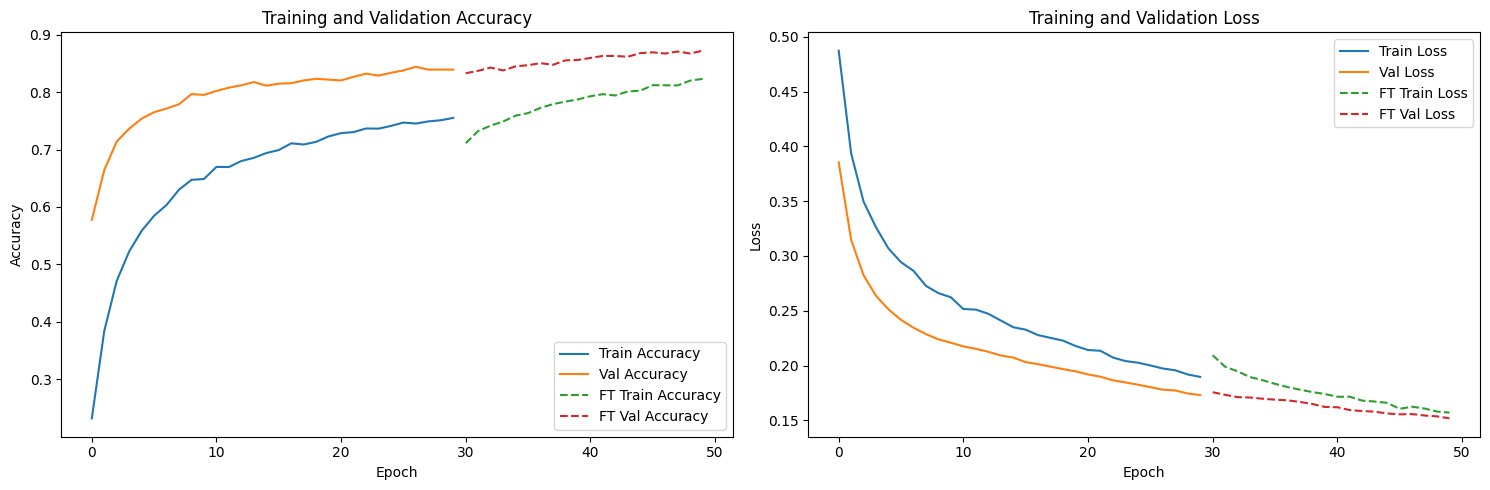

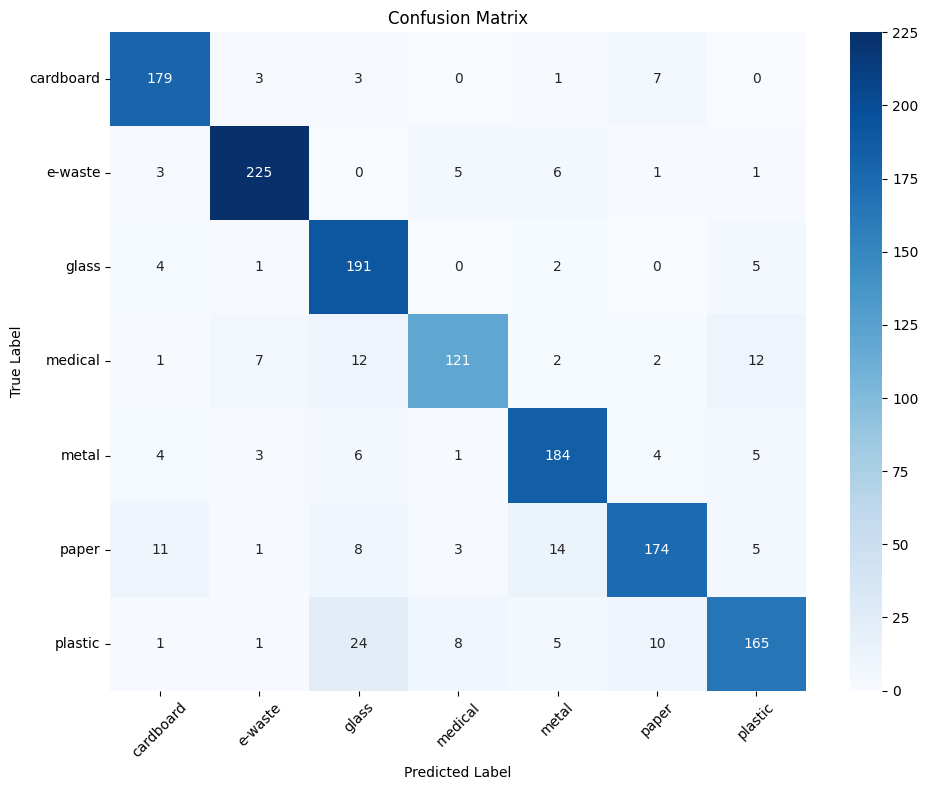


Top misclassified pairs (True -> Predicted):
  plastic      -> glass       : 24 samples
  paper        -> metal       : 14 samples
  medical      -> glass       : 12 samples
  medical      -> plastic     : 12 samples
  paper        -> cardboard   : 11 samples
  plastic      -> paper       : 10 samples
  paper        -> glass       :  8 samples
  plastic      -> medical     :  8 samples


In [26]:
# Cell 17: Enhanced Visualization Functions
def plot_training_history(history, history_ft=None):
    """Plot training history với cả hai phase"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    if history_ft:
        ax1.plot(range(EPOCHS, EPOCHS + len(history_ft.history['accuracy'])), 
                history_ft.history['accuracy'], label='FT Train Accuracy', linestyle='--')
        ax1.plot(range(EPOCHS, EPOCHS + len(history_ft.history['val_accuracy'])), 
                history_ft.history['val_accuracy'], label='FT Val Accuracy', linestyle='--')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.set_title('Training and Validation Accuracy')
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    if history_ft:
        ax2.plot(range(EPOCHS, EPOCHS + len(history_ft.history['loss'])), 
                history_ft.history['loss'], label='FT Train Loss', linestyle='--')
        ax2.plot(range(EPOCHS, EPOCHS + len(history_ft.history['val_loss'])), 
                history_ft.history['val_loss'], label='FT Val Loss', linestyle='--')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.set_title('Training and Validation Loss')
    
    plt.tight_layout()
    plt.show()

def plot_detailed_confusion_matrix(cm, class_names):
    """Plot confusion matrix chi tiết với phân tích"""
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Phân tích các cặp class dễ nhầm lẫn
    misclassified_pairs = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 3:  # Các cặp nhầm lẫn nhiều
                misclassified_pairs.append((class_names[i], class_names[j], cm[i, j]))
    
    print("\nTop misclassified pairs (True -> Predicted):")
    for true, pred, count in sorted(misclassified_pairs, key=lambda x: x[2], reverse=True)[:8]:
        print(f"  {true:12} -> {pred:12}: {count:2d} samples")

# Gọi các hàm visualization
plot_training_history(history, history_ft)
plot_detailed_confusion_matrix(cm, class_names)

In [27]:
# Cell 18: Save Final Model và Analysis Report
# Save final model
final_h5 = os.path.join(SAVE_DIR, 'waste_model_improved_final.h5')
model.save(final_h5)
print(f"Saved improved model to: {final_h5}")


Saved improved model to: models_improved\waste_model_improved_final.h5
